# 1. Libraries & Data Loading

We import data analysis, visualization, and machine learning libraries, then load the car price dataset.

In [10]:
# ===================================================
# 1. LIBRARIES & DATA LOADING
# ===================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("cardekho.csv")

# Clean column headers
df.columns = df.columns.str.strip()

# View first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


# 2. Data Cleaning & Feature Engineering

We handle missing values, compute the car's age, convert categorical text columns into numbers, and select features for modeling.

In [26]:
# ===================================================
# 2. DATA CLEANING & FEATURE ENGINEERING
# ===================================================
# Drop missing values
df = df.dropna()

# Calculate Car Age
df['Car_Age'] = 2026 - df['year']

# Extract numeric numbers safely by converting to string first
df['mileage(km/ltr/kg)'] = df['mileage(km/ltr/kg)'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)
df['engine'] = df['engine'].astype(str).str.extract(r'(\d+)').astype(float)
df['max_power'] = df['max_power'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

# Drop any missing values from extraction
df = df.dropna()

# Convert text/categorical columns into numbers
df = pd.get_dummies(df, drop_first=True)

# Separate input features (X) and target price (y)
X = df.drop(columns=['selling_price', 'year'])
y = df['selling_price']

# View clean numeric features
X.head()

,km_driven,mileage(km/ltr/kg),engine,max_power,seats,Car_Age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,name_Volvo V40 Cross Country D3,name_Volvo V40 D3 R-Design,name_Volvo XC40 D4 Inscription BSIV,name_Volvo XC40 D4 R-Design,name_Volvo XC60 Inscription D5 BSIV,name_Volvo XC90 T8 Excellence BSIV,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,145500,23.40,1248.0,74.00,5.0,12,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,120000,21.14,1498.0,103.52,5.0,12,True,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,140000,17.70,1497.0,78.00,5.0,20,False,False,True,True,...,False,False,False,False,False,False,False,False,False,True
3,127000,23.00,1396.0,90.00,5.0,16,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,120000,16.10,1298.0,88.20,5.0,19,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


# 3. Train-Test Split

We split the dataset into training (80%) and testing (20%) sets to evaluate how well our model predicts unseen car prices.

In [27]:
# ===================================================
# 3. TRAIN-TEST SPLIT
# ===================================================
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data rows:", len(X_train))
print("Testing data rows:", len(X_test))

Training data rows: 6324
Testing data rows: 1582


# 4. Model Training & Evaluation

We train a Linear Regression model on the training data and calculate metrics to measure prediction accuracy.

In [28]:
# ===================================================
# 4. MODEL TRAINING & EVALUATION
# ===================================================
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict car prices for test data
y_pred = model.predict(X_test)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 191349.96
R2 Score: 0.85


# 5. Visualizing Actual vs. Predicted Prices

We create a scatter plot to visually compare actual selling prices against predicted selling prices.

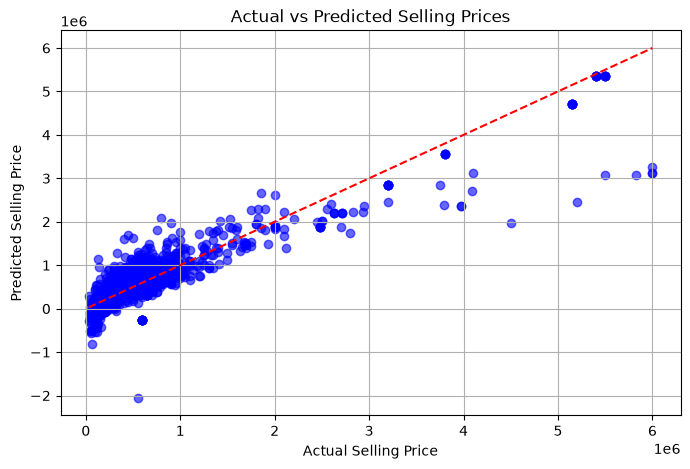

In [29]:
# ===================================================
# 5. VISUALIZING RESULTS
# ===================================================
plt.figure(figsize=(8, 5))

# Plot actual vs predicted prices
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.title('Actual vs Predicted Selling Prices')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.grid(True)
plt.show()